# Reinforcement Learning for Blackjack: Initial Checkpoint

**Authors:** CSE 25 Project Team

## 1. Introduction

### Problem Statement

The goal of this project is to train an agent to play Blackjack by treating it as a sequential decision-making problem under uncertainty. Unlike supervised learning, the agent has to figure out a good strategy through direct interaction with the environment — there are no labeled examples or known transition rules to rely on.

Blackjack is a good fit for RL: it has a small, fully enumerable state space, games are short and finite, and there's a well-known optimal strategy (Basic Strategy) we can compare against.

### Relevance and Importance

RL is behind some of the biggest AI breakthroughs in recent years — from game-playing agents like AlphaGo and AlphaStar to robotics and LLM alignment. The core challenge across all these domains — making sequential decisions under uncertainty with delayed feedback — is exactly what Blackjack exercises, but in a simple enough setting to understand well. Working through this environment helps build intuition for the explore/exploit tradeoff, value estimation, and policy improvement.

### Related Work

- **Basic Strategy:** Probability-based lookup tables define optimal moves based on the player's hand total and the dealer's upcard. This is the gold-standard human heuristic and serves as our rule-based baseline.
- **Monte Carlo Methods:** Sutton & Barto (*Reinforcement Learning: An Introduction*, 2nd ed.) use Blackjack as the canonical example for Monte Carlo policy evaluation and control, showing how agents learn from complete episode trajectories without a model of the environment.
- **Temporal Difference Learning:** Q-learning (Watkins, 1989) is a TD method that updates value estimates after every step rather than waiting for episode completion. Its convergence properties in tabular settings are well-characterized in the literature.

## 2. Data Sourcing and Processing

### The "Dataset"

Unlike supervised learning, RL doesn't use a fixed dataset — data is generated on the fly through interaction with the environment. We use the `Gymnasium` library's `Blackjack-v1` environment (`sab=True` for Sutton & Barto rules), where the agent plays hands and receives reward signals based on outcomes.

### State Space (Features)

Each observation is a tuple of three components:

| Feature | Description | Range |
|---|---|---|
| `player_sum` | Total value of the player's current hand | 4 – 21 |
| `dealer_card` | Dealer's single face-up card (Ace = 1) | 1 – 10 |
| `usable_ace` | Whether the player holds an ace counting as 11 | 0 or 1 |

The total discrete state space has $32 \times 11 \times 2 = 704$ possible states, though only a subset (roughly $200$) are actually reachable.

### Action Space

The standard `Blackjack-v1` environment offers exactly **two actions**:
- `0`: **Stand** — stop drawing cards.
- `1`: **Hit** — draw another card.

### Reward Structure

| Outcome | Reward |
|---|---|
| Player wins | +1.0 |
| Draw (push) | 0.0 |
| Player loses | -1.0 |

### Preprocessing

Since the state space is discrete and small, we don't need any preprocessing. The raw observation tuple is used directly as a dictionary key into each algorithm's Q-table.

## 3. Model Description

We implement and compare two tabular RL algorithms against simple baselines. Both represent the policy through a **Q-table** — a lookup table mapping each (state, action) pair to an estimated value.

### Model Architecture (shared)

- **Q-Table shape:** `dict` over reachable states → `np.array([Q_stand, Q_hit])`. At most $704 \times 2 = 1{,}408$ learnable floats.
- **Exploration:** Epsilon-greedy — with probability $\varepsilon$ take a random action, otherwise $\arg\max_a Q(s,a)$.
- **Epsilon schedule:** $\varepsilon_0 = 1.0$, decaying by $\times 0.99995$ per episode, flooring at $0.05$.

---

### Algorithm 1: On-Policy First-Visit Monte Carlo Control

MC methods learn from **complete episode trajectories**. After each episode, the agent computes the discounted return $G$ for each visited (state, action) pair and updates Q-values using an incremental mean — no bootstrapping.

$$Q(s, a) \leftarrow Q(s, a) + \frac{G - Q(s, a)}{N(s, a)}$$

Blackjack is a natural fit: episodes are short, finite, and rewards only come at termination.

---

### Algorithm 2: Tabular Q-Learning (Off-Policy TD)

Q-learning updates after **every step** using a bootstrapped one-step return:

$$Q(s, a) \leftarrow Q(s, a) + \alpha \left[ r + \gamma \max_{a'} Q(s', a') - Q(s, a) \right]$$

Off-policy means the update always targets the greedy value at $s'$, regardless of what exploratory action was actually taken. Hyperparameters: $\alpha = 0.1$, $\gamma = 1.0$.

---

### Baseline Comparisons

| Baseline | Description |
|---|---|
| **Random Policy** | Selects Hit or Stand uniformly at random |
| **Stand-on-17+ Heuristic** | Hit if player sum < 17, else Stand |

---

### Evaluation Metrics

- **Primary:** Average episodic return over a 100k-episode evaluation run (greedy policy, no exploration).
- **Secondary:** Win rate, draw rate, loss rate.
- **Training diagnostic:** Smoothed learning curve (rolling average return vs. training episode).

---
## 4. Environment Setup

In [1]:
# !pip install gymnasium matplotlib numpy tqdm

import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import defaultdict
from tqdm import tqdm

print(f"Gymnasium version: {gym.__version__}")

Gymnasium version: 1.2.3


In [2]:
env = gym.make('Blackjack-v1', sab=True)  # sab=True uses Sutton & Barto rules

print(f"Observation space: {env.observation_space}")
print(f"Action space:      {env.action_space}")
print(f"Actions: 0=Stand, 1=Hit")

Observation space: Tuple(Discrete(32), Discrete(11), Discrete(2))
Action space:      Discrete(2)
Actions: 0=Stand, 1=Hit


In [3]:
# Sample episodes to understand the environment
print("=== Sample Episodes ===")
for episode in range(3):
    state, _ = env.reset()
    print(f"\nEpisode {episode + 1}: start state = {state}")
    done = False
    step = 0
    while not done:
        action = env.action_space.sample()
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        step += 1
        print(f"  Step {step}: {'Hit' if action else 'Stand':5s}  ->  state={next_state}  reward={reward}")
        state = next_state
    result = 'Win' if reward > 0 else ('Draw' if reward == 0 else 'Lose')
    print(f"  Result: {result}")

=== Sample Episodes ===

Episode 1: start state = (14, 10, 0)
  Step 1: Hit    ->  state=(24, 10, 0)  reward=-1.0
  Result: Lose

Episode 2: start state = (17, 8, 0)
  Step 1: Stand  ->  state=(17, 8, 0)  reward=-1.0
  Result: Lose

Episode 3: start state = (13, 6, 0)
  Step 1: Hit    ->  state=(16, 6, 0)  reward=0.0
  Step 2: Stand  ->  state=(16, 6, 0)  reward=-1.0
  Result: Lose


---
## 5. Baseline Policies

Before training any RL agent, we establish two simple baselines to have something to compare against.

`evaluate_policy` reports the **average episodic return** (primary metric) and win/draw/loss rates.

In [4]:
def evaluate_policy(env, policy_fn, n_episodes=100_000):
    """
    Evaluate a greedy policy over many episodes (no exploration).
    Returns a dict: avg_return, win_rate, draw_rate, lose_rate.
    """
    wins, draws, losses = 0, 0, 0
    total_return = 0.0
    for _ in range(n_episodes):
        state, _ = env.reset()
        done = False
        ep_return = 0.0
        while not done:
            action = policy_fn(state)
            state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            ep_return += reward
        total_return += ep_return
        if reward > 0:   wins += 1
        elif reward == 0: draws += 1
        else:            losses += 1
    return dict(
        avg_return = total_return / n_episodes,
        win_rate   = wins   / n_episodes,
        draw_rate  = draws  / n_episodes,
        lose_rate  = losses / n_episodes,
    )


def print_results(label, results):
    print(f"{label:<30}  avg_return={results['avg_return']:+.4f}  "
          f"win={results['win_rate']:.2%}  draw={results['draw_rate']:.2%}  lose={results['lose_rate']:.2%}")

In [ ]:
def random_policy(state):
    return env.action_space.sample()

def threshold_policy(state):
    if state[0] < 17:
        return 1  # Hit
    return 0      # Stand

baseline_random    = evaluate_policy(env, random_policy)
baseline_threshold = evaluate_policy(env, threshold_policy)

print_results("Random Policy",          baseline_random)
print_results("Stand-on-17+ Heuristic", baseline_threshold)

In [ ]:
# Stacked bar chart: Win / Draw / Lose breakdown for baselines
labels  = ["Random Policy", "Stand-on-17+"]
results = [baseline_random, baseline_threshold]

wins  = []
draws = []
loses = []
for r in results:
    wins.append(r['win_rate'])
    draws.append(r['draw_rate'])
    loses.append(r['lose_rate'])

x = np.arange(len(labels))
bar_w = 0.45

fig, ax = plt.subplots(figsize=(7, 5))
bars_w = ax.bar(x, wins,  bar_w, label='Win',  color='#4575b4')
bars_d = ax.bar(x, draws, bar_w, label='Draw', color='#fee090', bottom=wins)

bottoms = []
for w, d in zip(wins, draws):
    bottoms.append(w + d)
bars_l = ax.bar(x, loses, bar_w, label='Lose', color='#d73027', bottom=bottoms)

for bar, r in zip(bars_w, results):
    ax.text(bar.get_x() + bar.get_width() / 2,
            r['avg_return'] + 0.51, f"avg return\n{r['avg_return']:+.3f}",
            ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('Fraction of Episodes')
ax.set_title('Baseline Policy Outcomes')
ax.set_ylim(0, 1.15)
ax.legend(loc='upper right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

---
## 6. Monte Carlo Control

### What is Monte Carlo RL?

Monte Carlo methods estimate value functions by averaging returns from complete episode trajectories. The agent plays a full hand, sees the final reward, then looks back at every (state, action) pair it visited and updates Q-values based on the actual return received.

### Algorithm: First-Visit MC Control

1. **Generate episode** using epsilon-greedy policy.
2. **Compute returns** backward: $G_t = r_t + \gamma r_{t+1} + \gamma^2 r_{t+2} + \cdots$
3. **Update Q-values** for each *(state, action)* visited for the first time in the episode:
   $$Q(s, a) \leftarrow Q(s, a) + \frac{G - Q(s, a)}{N(s, a)}$$
4. **Decay epsilon** to shift from exploration toward exploitation.

In [ ]:
def train_monte_carlo(
    env,
    n_episodes=500_000,
    gamma=1.0,
    epsilon_start=1.0,
    epsilon_min=0.05,
    epsilon_decay=0.99995,
    seed=42,
):
    rng = np.random.default_rng(seed)
    Q = defaultdict(lambda: np.zeros(env.action_space.n, dtype=np.float64))
    returns_count = defaultdict(lambda: np.zeros(env.action_space.n))
    epsilon = float(epsilon_start)
    ep_returns = []

    for _ in tqdm(range(n_episodes), desc="MC Training", leave=False):
        state, _ = env.reset()
        episode = []
        done = False

        # Generate episode
        while not done:
            action = env.action_space.sample() if rng.random() < epsilon else int(np.argmax(Q[state]))
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            episode.append((state, action, reward))
            state = next_state

        ep_sum = 0.0
        for _, _, r in episode:
            ep_sum += r
        ep_returns.append(ep_sum)

        # First-visit MC update (backward)
        G = 0.0
        visited = set()
        for s, a, r in reversed(episode):
            G = gamma * G + r
            if (s, a) not in visited:
                visited.add((s, a))
                returns_count[s][a] += 1
                Q[s][a] += (G - Q[s][a]) / returns_count[s][a]

        epsilon = max(epsilon_min, epsilon * epsilon_decay)

    return Q, ep_returns

In [ ]:
mc_Q, mc_returns = train_monte_carlo(env, n_episodes=500_000)

def mc_policy(state):
    return int(np.argmax(mc_Q[state]))

mc_results = evaluate_policy(env, mc_policy)
print_results("Monte Carlo Control", mc_results)

---
## 7. Tabular Q-Learning (Off-Policy TD)

Q-learning updates the Q-table after **every step** using a bootstrapped one-step return:

$$Q(s, a) \leftarrow Q(s, a) + \alpha \left[ r + \gamma \max_{a'} Q(s', a') - Q(s, a) \right]$$

The $\max_{a'}$ makes it **off-policy** — updates always use the greedy value at $s'$, even when the agent is exploring. This tends to converge faster than MC since the agent learns from every transition, not just at the end of an episode.

In [9]:
def train_q_learning(
    env,
    n_episodes=500_000,
    alpha=0.1,
    gamma=1.0,
    epsilon_start=1.0,
    epsilon_min=0.05,
    epsilon_decay=0.99995,
    seed=42,
):
    rng = np.random.default_rng(seed)
    Q = defaultdict(lambda: np.zeros(env.action_space.n, dtype=np.float32))
    epsilon = float(epsilon_start)
    ep_returns = []

    for _ in tqdm(range(n_episodes), desc="Q-Learning Training", leave=False):
        s, _ = env.reset()
        done = False
        ep_return = 0.0

        while not done:
            # Epsilon-greedy action selection
            a = env.action_space.sample() if rng.random() < epsilon else int(np.argmax(Q[s]))

            s2, r, terminated, truncated, _ = env.step(a)
            done = terminated or truncated
            ep_return += r

            # Q-learning update
            best_next = 0.0 if done else float(np.max(Q[s2]))
            Q[s][a] += alpha * (r + gamma * best_next - float(Q[s][a]))
            s = s2

        ep_returns.append(ep_return)
        epsilon = max(epsilon_min, epsilon * epsilon_decay)

    return Q, ep_returns

In [ ]:
ql_Q, ql_returns = train_q_learning(env, n_episodes=500_000)

def ql_policy(state):
    return int(np.argmax(ql_Q[state]))

ql_results = evaluate_policy(env, ql_policy)
print_results("Q-Learning", ql_results)

---
## 8. Results and Comparison

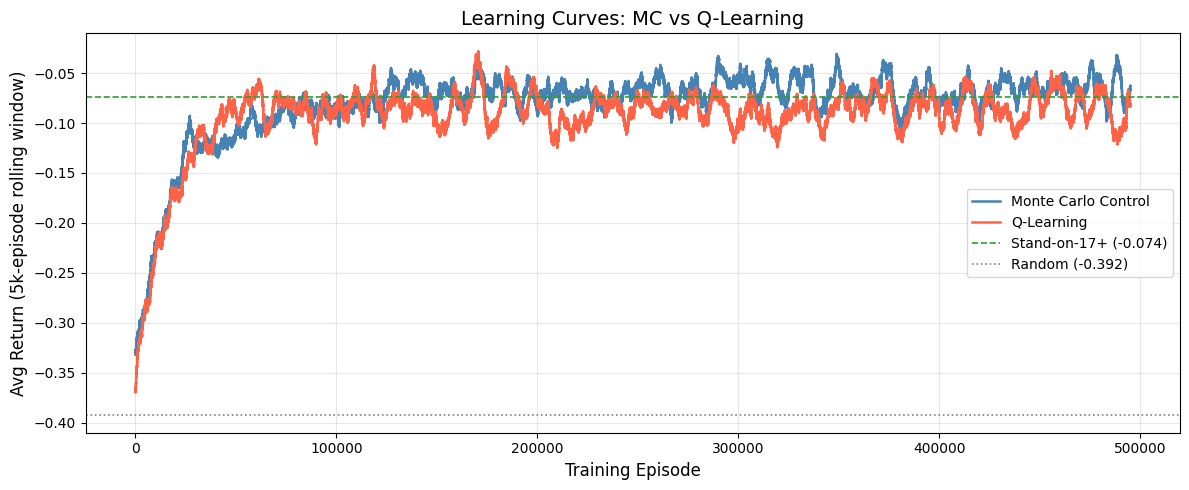

In [11]:
# --- Learning Curves ---
def smooth(data, window=5_000):
    return np.convolve(data, np.ones(window) / window, mode='valid')


fig, ax = plt.subplots(figsize=(12, 5))

for returns, label, color in [
    (mc_returns, 'Monte Carlo Control', 'steelblue'),
    (ql_returns, 'Q-Learning',          'tomato'),
]:
    s = smooth(returns, window=5_000)
    ax.plot(np.arange(len(s)), s, label=label, color=color, linewidth=1.8)

# Baseline reference lines
ax.axhline(y=baseline_threshold['avg_return'], color='#2ca02c', linestyle='--',
           linewidth=1.2, label=f"Stand-on-17+ ({baseline_threshold['avg_return']:+.3f})")
ax.axhline(y=baseline_random['avg_return'], color='gray', linestyle=':',
           linewidth=1.2, label=f"Random ({baseline_random['avg_return']:+.3f})")

ax.set_xlabel('Training Episode', fontsize=12)
ax.set_ylabel('Avg Return (5k-episode rolling window)', fontsize=12)
ax.set_title('Learning Curves: MC vs Q-Learning', fontsize=14)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# --- Final Evaluation Bar Chart ---
all_labels  = ["Random", "Stand-on-17+", "Monte Carlo", "Q-Learning"]
all_results = [baseline_random, baseline_threshold, mc_results, ql_results]
colors      = ['#aec7e8', '#ffbb78', 'steelblue', 'tomato']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Avg Return
returns = []
for r in all_results:
    returns.append(r['avg_return'])

axes[0].bar(all_labels, returns, color=colors, edgecolor='white', linewidth=0.8)
for i, v in enumerate(returns):
    axes[0].text(i, v + (0.004 if v >= 0 else -0.010), f"{v:+.3f}",
                 ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_ylabel('Average Episodic Return')
axes[0].set_title('Average Return (100k eval episodes)')
axes[0].grid(axis='y', alpha=0.3)

# Win Rate
win_rates = []
for r in all_results:
    win_rates.append(r['win_rate'])

axes[1].bar(all_labels, win_rates, color=colors, edgecolor='white', linewidth=0.8)
for i, v in enumerate(win_rates):
    axes[1].text(i, v + 0.004, f"{v:.1%}",
                 ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[1].set_ylabel('Win Rate')
axes[1].set_title('Win Rate (100k eval episodes)')
axes[1].set_ylim(0, 0.60)
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Final Policy Evaluation', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# --- Policy Heatmaps ---
def plot_policy_heatmap(Q, title):
    """
    Visualize the greedy policy learned by a Q-table.
    Rows = player sum (12-21), Cols = dealer showing (1-10).
    Blue = Hit, Red = Stand. Left panel: no usable ace. Right: usable ace.
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(title, fontsize=13)

    for ax, usable_ace in zip(axes, [False, True]):
        player_sums  = range(12, 22)
        dealer_cards = range(1, 11)
        policy_grid  = np.zeros((len(player_sums), len(dealer_cards)))

        for i, ps in enumerate(player_sums):
            for j, dc in enumerate(dealer_cards):
                state = (ps, dc, int(usable_ace))
                policy_grid[i, j] = int(np.argmax(Q[state]))

        # Custom colormap: 0=Stand (red), 1=Hit (blue)
        cmap = plt.cm.colors.ListedColormap(['#d73027', '#4575b4'])
        ax.imshow(policy_grid, cmap=cmap, vmin=0, vmax=1,
                  aspect='auto', origin='upper')

        # Grid lines and labels
        ax.set_xticks(np.arange(10))
        x_labels = []
        for c in dealer_cards:
            if c == 1:
                x_labels.append('A')
            else:
                x_labels.append(str(c))
        ax.set_xticklabels(x_labels)
        ax.set_yticks(np.arange(len(player_sums)))
        ax.set_yticklabels(list(player_sums))
        ax.set_xlabel('Dealer Showing')
        ax.set_ylabel('Player Sum')
        ace_label = 'Usable Ace' if usable_ace else 'No Usable Ace'
        ax.set_title(ace_label)

        # Draw grid
        ax.set_xticks(np.arange(-0.5, 10, 1), minor=True)
        ax.set_yticks(np.arange(-0.5, 10, 1), minor=True)
        ax.grid(which='minor', color='white', linewidth=0.5)

    stand_patch = mpatches.Patch(color='#d73027', label='Stand (0)')
    hit_patch   = mpatches.Patch(color='#4575b4', label='Hit (1)')
    fig.legend(handles=[stand_patch, hit_patch], loc='lower center',
               ncol=2, bbox_to_anchor=(0.5, -0.05), fontsize=11)
    plt.tight_layout()
    plt.show()


plot_policy_heatmap(mc_Q, 'Monte Carlo Control — Learned Policy')
plot_policy_heatmap(ql_Q, 'Q-Learning — Learned Policy')

In [14]:
# --- Summary Table ---
print(f"{'Algorithm':<28} {'Avg Return':>12} {'Win Rate':>10} {'Draw Rate':>11} {'Lose Rate':>11}")
print("-" * 76)
for label, r in zip(all_labels, all_results):
    print(f"{label:<28} {r['avg_return']:>+12.4f} {r['win_rate']:>10.2%} {r['draw_rate']:>11.2%} {r['lose_rate']:>11.2%}")

Algorithm                      Avg Return   Win Rate   Draw Rate   Lose Rate
----------------------------------------------------------------------------
Random                            -0.3919     28.38%       4.05%      67.57%
Stand-on-17+                      -0.0741     41.21%      10.17%      48.62%
Monte Carlo                       -0.0438     43.65%       8.32%      48.03%
Q-Learning                        -0.0619     42.61%       8.60%      48.80%
